# Influence of the sea in ERT measurements

When measuring an ERT profile close to the sea, the conductive seawater body can have a significant influence on the measurements. This notebook demonstrates how to include the sea in the modelling of ERT data using the `pygimli` library.

![Sketch](sketch.png)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pygimli as pg
import pygimli.meshtools as mt
from pygimli.physics import ert

We first load the ERT data file.

09/01/26 - 12:27:18 - pyGIMLi - INFO - could not read unified data format for ERT ... try res2dinv


Data: Sensors: 130 data: 2688, nonzero entries: ['a', 'b', 'k', 'm', 'n', 'rhoa', 'valid']


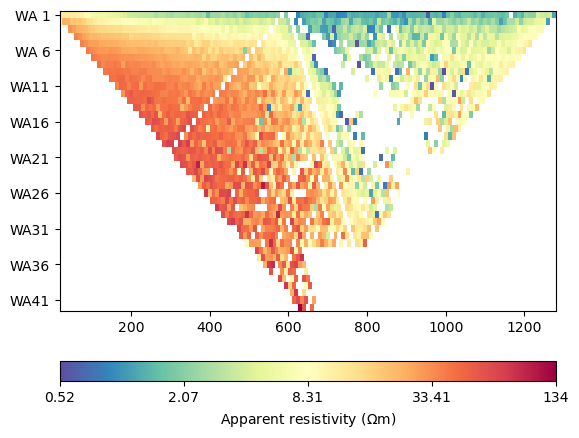

In [2]:
data = ert.load('Line10_notopo.dat')
data["k"] = ert.geometricFactors(data)
print(data)
data.remove(data["rhoa"] <= 0.5)
data.remove(data["rhoa"] > 150)
data.remove(data["b"] == 60)
ert.show(data);

In [3]:
ex = pg.x(data)
print(min(ex), max(ex))
bnd = 1000
world = mt.createWorld(start=[min(ex)-bnd, -bnd, -bnd], end=[max(ex)+bnd, bnd, 0], marker=1)

0.0 1290.0


In [4]:
sea = mt.createCube(start=[min(ex)-bnd, 100, -2], end=[max(ex)+bnd, bnd, 0], marker=2, boundaryMarker=True)
[print(n.pos()) for n in sea.nodes()]

RVector3: (-1000.0, 100.0, -2.0)
RVector3: (2290.0, 100.0, -2.0)
RVector3: (2290.0, 100.0, 0.0)
RVector3: (-1000.0, 100.0, 0.0)
RVector3: (-1000.0, 1000.0, -2.0)
RVector3: (2290.0, 1000.0, -2.0)
RVector3: (2290.0, 1000.0, 0.0)
RVector3: (-1000.0, 1000.0, 0.0)


[None, None, None, None, None, None, None, None]

In [5]:
for i in [4, 5]:
    pos = sea.node(i).pos()
    pos.setZ(-20)
    print(pos)
    sea.node(i).setPos(pos)
# pg.show(sea)

RVector3: (-1000.0, 1000.0, -20.0)
RVector3: (2290.0, 1000.0, -20.0)


In [6]:
geo = world + sea
for sen in data.sensors():
    geo.createNode(sen)

mesh = mt.createMesh(geo, quality=1.5)
print(mesh)
mesh.populate("res", {1:10, 2:0.2})
mesh.exportVTK("seaMesh.vtk")

Mesh: Nodes: 185039 Cells: 928138 Boundaries: 1926765


c:\software\miniforge\envs\pgdev\Lib\site-packages\pyvista\jupyter\notebook.py:56: UserWarning: Failed to use notebook backend: 

cannot import name 'vuetify' from 'trame.widgets' (c:\software\miniforge\envs\pgdev\Lib\site-packages\trame\widgets\__init__.py)

Falling back to a static output.
  warnings.warn(


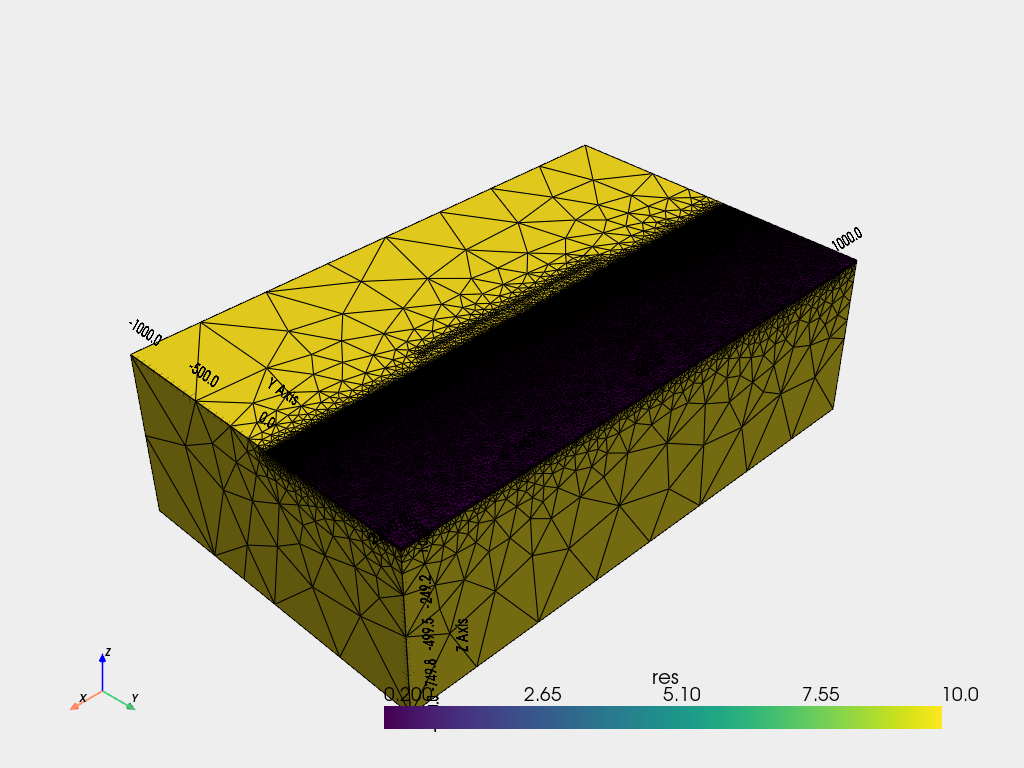

In [7]:
pl, _ = pg.show(mesh, showMesh=True)

In [8]:
data = ert.simulate(mesh, scheme=data, res=mesh["res"])
data.remove(data["rhoa"] <= 0)
data.save('Line10_sea_simulated.dat', 'a b m n k rhoa')

1

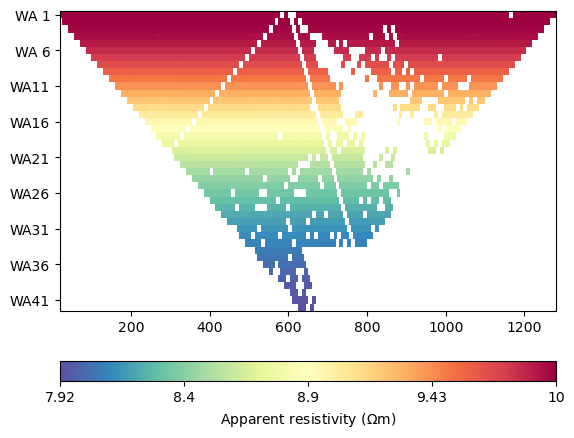

In [9]:
data.show();